In [283]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from neural_net import NeuralNet
import mushrooms as shroom
import graphics
from sklearn.datasets import load_breast_cancer

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [284]:
df: pd.DataFrame = load_breast_cancer(as_frame=True).frame # type: ignore

df[df["target"] != 0]

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
19,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,0.05766,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,1
20,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,0.06811,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,1
21,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,0.06905,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,1
37,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,0.05863,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,1
46,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,0.06503,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558,14.590,22.68,96.39,657.1,0.08473,0.13300,0.10290,0.037360,0.1454,0.06147,...,27.27,105.90,733.5,0.10260,0.31710,0.36620,0.11050,0.2258,0.08004,1
559,11.510,23.93,74.52,403.5,0.09261,0.10210,0.11120,0.041050,0.1388,0.06570,...,37.16,82.28,474.2,0.12980,0.25170,0.36300,0.09653,0.2112,0.08732,1
560,14.050,27.15,91.38,600.4,0.09929,0.11260,0.04462,0.043040,0.1537,0.06171,...,33.17,100.20,706.7,0.12410,0.22640,0.13260,0.10480,0.2250,0.08321,1
561,11.200,29.37,70.67,386.0,0.07449,0.03558,0.00000,0.000000,0.1060,0.05502,...,38.30,75.19,439.6,0.09267,0.05494,0.00000,0.00000,0.1566,0.05905,1


In [285]:
X, y = load_breast_cancer(return_X_y=True)
X = np.array(X, dtype=float)
y = np.array(y, dtype=float)
print(f"Shape of data:\n    X: {X.shape},\n    y: {y.shape}")

Shape of data:
    X: (569, 30),
    y: (569,)


In [286]:
neural_net = NeuralNet((30, 512, 1), learning_rate=0.0001, random_state=42)
epochs = 300
losses, y_pred = neural_net.train(X[0:-100], y[0:-100], epochs, 1, validate=(X[-100:], y[-100:]), binary=True) # type: ignore

EPOCH: 1    LOSS: 0.665513    LOSS CHANGE: 0    TEST ACCURACY: 0.79    TEST ACCURACY CHANGE: 0.79
EPOCH: 2    LOSS: 0.538543    LOSS CHANGE: -0.127    TEST ACCURACY: 0.9    TEST ACCURACY CHANGE: 0.11
EPOCH: 3    LOSS: 0.501526    LOSS CHANGE: -0.03702    TEST ACCURACY: 0.9    TEST ACCURACY CHANGE: 0
EPOCH: 4    LOSS: 0.464576    LOSS CHANGE: -0.03695    TEST ACCURACY: 0.9    TEST ACCURACY CHANGE: 0
EPOCH: 5    LOSS: 0.430662    LOSS CHANGE: -0.03391    TEST ACCURACY: 0.9    TEST ACCURACY CHANGE: 0
EPOCH: 6    LOSS: 0.407841    LOSS CHANGE: -0.02282    TEST ACCURACY: 0.9    TEST ACCURACY CHANGE: 0
EPOCH: 7    LOSS: 0.381113    LOSS CHANGE: -0.02673    TEST ACCURACY: 0.89    TEST ACCURACY CHANGE: -0.01
EPOCH: 8    LOSS: 0.364757    LOSS CHANGE: -0.01636    TEST ACCURACY: 0.9    TEST ACCURACY CHANGE: 0.01
EPOCH: 9    LOSS: 0.351936    LOSS CHANGE: -0.01282    TEST ACCURACY: 0.9    TEST ACCURACY CHANGE: 0
EPOCH: 10    LOSS: 0.342372    LOSS CHANGE: -0.009564    TEST ACCURACY: 0.9    TEST A

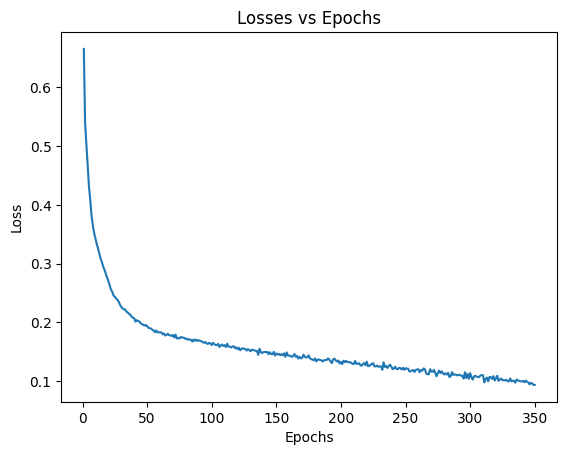

In [287]:
graphics.plot_losses(epochs, losses)

In [288]:
from sklearn.metrics import accuracy_score

y_pred = neural_net.predict(X[-100:])
y_pred_abs = np.where(y_pred >= 0.5, 1, 0)
accuracy = accuracy_score(y_pred_abs, y[-100:])
print(f"Test Data Accuracy: {100*accuracy}%")

Test Data Accuracy: 94.0%


In [289]:
print(neural_net.BCE(y_pred.flatten(), y[-100:])) # type:ignore

0.175032186905792


In [290]:
y_pred = neural_net.batch_eval(X) # type: ignore
y_pred_abs = np.where(y_pred >= 0.5, 1, 0)
df["target predicted"] = y_pred_abs.flatten()
df[df["target"] != df["target predicted"]]
df[df["target"] == df["target predicted"]]
print(f"Percent accuracy on total data: {100*np.sum(df["target"] == df["target predicted"])/len(df["target"]):.4g}%")

Percent accuracy on total data: 96.13%


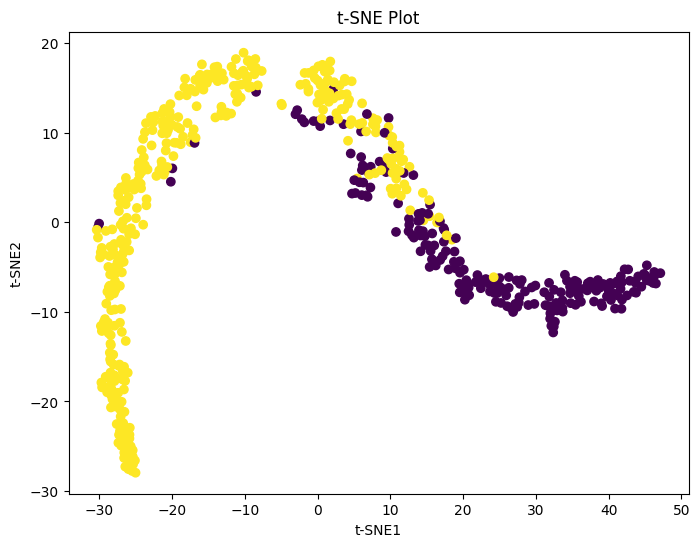

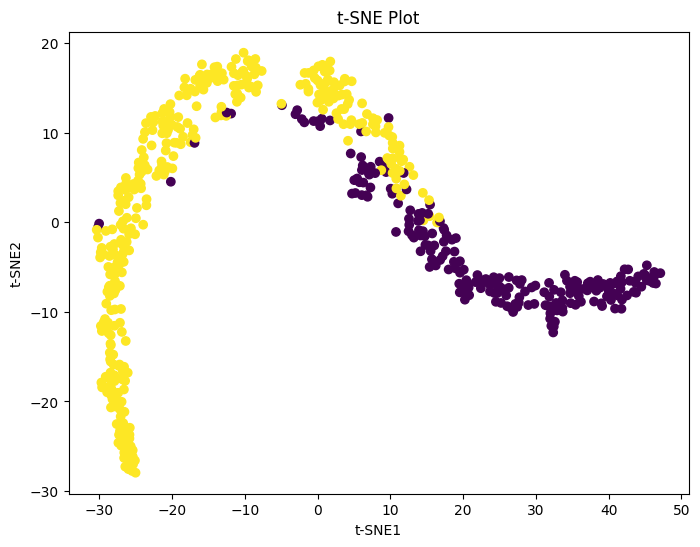

In [291]:
from sklearn.manifold import TSNE

def t_sne(df, df_target):
    X = df.drop(columns=["target", "target predicted"])
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    X_embedded = tsne.fit_transform(X)
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X_embedded[:, 0],
                X_embedded[:, 1],
                c=df_target)
    handles, labels = scatter.legend_elements()
    plt.title('t-SNE Plot')
    plt.xlabel('t-SNE1')
    plt.ylabel('t-SNE2')
    plt.show()

t_sne(df, df["target"])
t_sne(df, df["target predicted"])
    

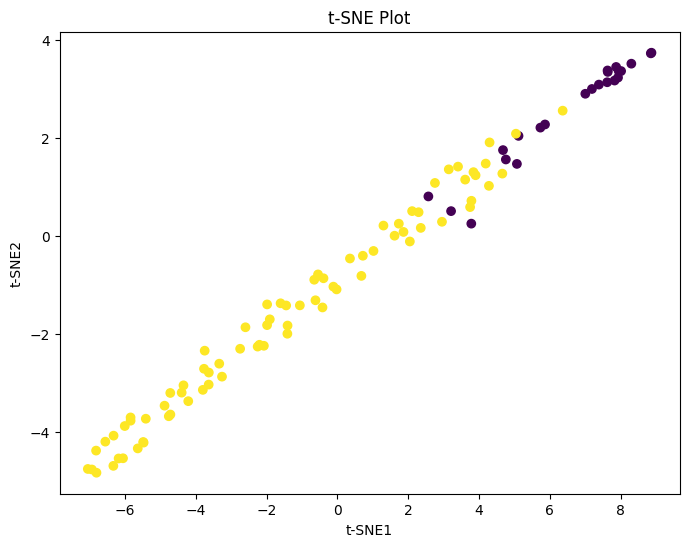

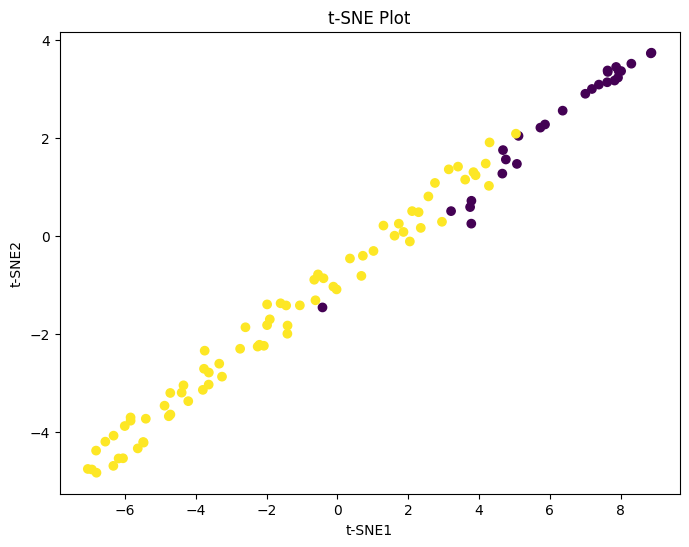

In [292]:
t_sne(df[-100:], df["target"][-100:])
t_sne(df[-100:], df["target predicted"][-100:])
    

In [293]:

true_positives = df[(df["target"] == 1) & (df["target"] == df["target predicted"])]
false_positives = df[(df["target"] == 1) & (df["target"] != df["target predicted"])]

true_negatives = df[(df["target"] == 0) & (df["target"] == df["target predicted"])]
false_negatives = df[(df["target"] == 0) & (df["target"] != df["target predicted"])]


false_discovery_rate = len(false_positives)/(len(false_positives) + len(true_positives))
false_positive_rate = len(false_positives)/(len(false_positives) + len(true_negatives))
print(f"False Discovery Rate: {100 * false_discovery_rate:.4g}%")
print(f"False Positive Rate: {100 * false_positive_rate:.4g}%")



False Discovery Rate: 3.922%
False Positive Rate: 6.422%
